## Imports and paths

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (precision_score,  recall_score,  roc_auc_score,  accuracy_score,  f1_score,  confusion_matrix,  roc_curve )

## 1. Modeling preparation


In [2]:
DATA_DIR = Path("../Cleaned Data/Splits")  # Training and test set folder
RANDOM_STATE = 1948883                     # Using My ID as a random seed, make the results reproducible.
N_SPLITS = 5                               # 5-fold cross-validation
N_ITER_SEARCH = 40                         # Number of random hyperparameter combinations tested in RandomizedSearchCV.
TOP_N_FEATURES = 15                        # Number of most important features to display in feature-importance plots.


# 4 modeling tasks.
TASKS = {
    "before_mask": "Before mandate - Face mask",                    # 1. Predict face mask behavior before the mask mandate.
    "after_mask": "After mandate - Face mask",                      # 2. Predict face mask behavior after the mask mandate.
    "before_protective": "Before mandate - Protective behaviour",   # 3. Predict protective behavior before the mask mandate.
    "after_protective": "After mandate - Protective behaviour",     # 4. Predict protective behavior after the mask mandate.
}


# Evaluation indicators
METRICS = ["precision", "recall", "roc_auc", "accuracy", "f1"]

## 2. Define Model


In [ ]:
# Read the corresponding training and test sets based on the task name.
def load_task(task):
    X_train = pd.read_csv(DATA_DIR / f"X_train_{task}.csv")
    X_test = pd.read_csv(DATA_DIR / f"X_test_{task}.csv")
    y_train = pd.read_csv(DATA_DIR / f"y_train_{task}.csv").iloc[:, 0].astype(int)
    y_test = pd.read_csv(DATA_DIR / f"y_test_{task}.csv").iloc[:, 0].astype(int)
    return X_train, X_test, y_train, y_test


# Build the Random Forest pipeline.
def build_pipeline():
    return Pipeline(steps=[
        ("ros", RandomOverSampler(random_state=RANDOM_STATE)),
        ("model", RandomForestClassifier(
            n_estimators=250,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])


# Hyperparameter search space for the Random Forest model.
def get_param_distributions():
    return {
        "model__max_depth": [5, 8, 10, 12, 15, 20, None],
        "model__min_samples_split": [2, 5, 10, 20, 30],
        "model__min_samples_leaf": [1, 2, 5, 10],
        "model__max_features": ["sqrt", "log2", 0.3, 0.5, 0.7, None],
        "model__bootstrap": [True],
    }


# Build RandomizedSearchCV for hyperparameter tuning.
def build_search():
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    search = RandomizedSearchCV(
        estimator=build_pipeline(),
        param_distributions=get_param_distributions(),
        n_iter=N_ITER_SEARCH,
        scoring="roc_auc",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=1,
        refit=True,
        verbose=0,
        return_train_score=False,
    )
    return search


# Calculate evaluation indicators.
def get_metrics(y_true, y_pred, y_prob):
    return {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


# Save model outputs and summary tables.
results = {}                       # Detailed results for each task
cv_summary = []                    # Average cross-validation result for each task
test_summary = []                  # Final results on the test set
search_summary = []                # search summary


## 3. Model training and prediction


In [5]:
# Perform Random Forest modeling on the 4 tasks.
# The best hyperparameters are selected by 5-fold stratified cross-validation.

for task, label in TASKS.items():
    X_train, X_test, y_train, y_test = load_task(task)
    search = build_search()
    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    best_params = search.best_params_
    best_cv_auc = search.best_score_

    cv_results_df = pd.DataFrame(search.cv_results_).sort_values("rank_test_score")  # cv results

    search_row = {"task": task,  "label": label,  "best_cv_auc": best_cv_auc, **best_params}
    search_summary.append(search_row)

    # Recalculate fold-level CV metrics using the selected best hyperparameters.
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    cv_rows = []


    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        fold_model = build_pipeline()
        fold_model.set_params(**best_params)
        fold_model.fit(X_tr, y_tr)
        y_val_pred = fold_model.predict(X_val)
        y_val_prob = fold_model.predict_proba(X_val)[:, 1]
        row = get_metrics(y_val, y_val_pred, y_val_prob)
        row["fold"] = fold
        cv_rows.append(row)

    cv_df = pd.DataFrame(cv_rows)
    cv_mean = cv_df[METRICS].mean().to_dict()
    cv_mean["task"] = task
    cv_mean["label"] = label
    cv_summary.append(cv_mean)


    # Predict on the final test set using the best refitted model.
    y_test_pred = best_model.predict(X_test)
    y_test_prob = best_model.predict_proba(X_test)[:, 1]
    test_row = get_metrics(y_test, y_test_pred, y_test_prob)
    test_row["task"] = task
    test_row["label"] = label
    test_summary.append(test_row)


    # Extract feature importance from the fitted Random Forest model.
    fitted_rf = best_model.named_steps["model"]
    importance_df = pd.DataFrame({"feature": X_train.columns,  "importance": fitted_rf.feature_importances_}).sort_values("importance", ascending=False)


    # save results
    results[task] = {
        "label": label,
        "best_model": best_model,
        "best_params": best_params,
        "best_cv_auc": best_cv_auc,
        "cv_df": cv_df,
        "cv_results_df": cv_results_df,
        "test_metrics": test_row,
        "y_test": y_test,
        "y_test_pred": y_test_pred,
        "y_test_prob": y_test_prob,
        "importance_df": importance_df,
        "cm": confusion_matrix(y_test, y_test_pred)}


## 4. Results


### 4.1 Cross-validation average


In [6]:
# Display the average performance across the 5 validation folds.
cv_summary_df = pd.DataFrame(cv_summary)[["task", "label"] + METRICS]

print("CV mean results")
display(cv_summary_df.round(4))

CV mean results


,task,label,precision,recall,roc_auc,accuracy,f1
0,before_mask,Before mandate - Face mask,0.6162,0.7007,0.8568,0.7941,0.6554
1,after_mask,After mandate - Face mask,0.8904,0.8930,0.8898,0.8471,0.8917
2,before_protective,Before mandate - Protective behaviour,0.7040,0.7111,0.7848,0.7100,0.7073
3,after_protective,After mandate - Protective behaviour,0.8539,0.8138,0.8352,0.7732,0.8333


### 4.2 Final test set results


In [7]:
# Display the final model performance on the independent test set.
test_summary_df = pd.DataFrame(test_summary)[["task", "label"] + METRICS]

print("Test results")
display(test_summary_df.round(4))

Test results


,task,label,precision,recall,roc_auc,accuracy,f1
0,before_mask,Before mandate - Face mask,0.6090,0.6846,0.8611,0.7888,0.6446
1,after_mask,After mandate - Face mask,0.8966,0.8903,0.8949,0.8504,0.8934
2,before_protective,Before mandate - Protective behaviour,0.6968,0.7078,0.7796,0.7043,0.7023
3,after_protective,After mandate - Protective behaviour,0.8524,0.8092,0.8363,0.7694,0.8303


### 4.3 Best hyperparameters


In [8]:
# Display the best hyperparameters selected by RandomizedSearchCV for each task.
search_summary_df = pd.DataFrame(search_summary)

print("Best hyperparameters selected by RandomizedSearchCV")
display(search_summary_df.round(6))

Best hyperparameters selected by RandomizedSearchCV


,task,label,best_cv_auc,model__min_samples_split,model__min_samples_leaf,model__max_features,model__max_depth,model__bootstrap
0,before_mask,Before mandate - Face mask,0.856848,10,5,0.3,NaN,True
1,after_mask,After mandate - Face mask,0.889834,5,5,0.5,15.0,True
2,before_protective,Before mandate - Protective behaviour,0.784808,5,1,0.5,NaN,True
3,after_protective,After mandate - Protective behaviour,0.835226,10,5,0.3,NaN,True


### 4.4 Top search results


In [9]:
# Display the top 10 hyperparameter combinations from the randomized search.
show_cols = ["rank_test_score", "mean_test_score", "std_test_score", "param_model__max_depth", "param_model__min_samples_split", "param_model__min_samples_leaf", "param_model__max_features", "param_model__bootstrap",]

for task, label in TASKS.items():
    print(label)
    display(results[task]["cv_results_df"][show_cols].head(10).round(6))


Before mandate - Face mask


,rank_test_score,mean_test_score,std_test_score,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,param_model__bootstrap
20,1,0.856848,0.010295,None,10,5,0.3,True
16,2,0.855593,0.009750,None,5,1,0.5,True
29,3,0.855331,0.010449,None,5,5,0.5,True
14,4,0.854546,0.010321,15,5,5,0.5,True
15,5,0.853384,0.010528,20,20,2,0.5,True
31,6,0.852322,0.011807,15,20,5,sqrt,True
4,7,0.852109,0.011520,12,5,10,0.3,True
32,8,0.851935,0.009865,12,2,2,0.7,True
19,9,0.851823,0.010667,12,30,2,0.5,True
18,10,0.851756,0.010649,15,10,1,0.7,True


After mandate - Face mask


,rank_test_score,mean_test_score,std_test_score,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,param_model__bootstrap
14,1,0.889834,0.006927,15,5,5,0.5,True
20,2,0.889736,0.006644,None,10,5,0.3,True
29,3,0.889723,0.007143,None,5,5,0.5,True
16,4,0.889474,0.006797,None,5,1,0.5,True
15,5,0.888817,0.006946,20,20,2,0.5,True
32,6,0.887836,0.007148,12,2,2,0.7,True
3,7,0.887517,0.007370,None,20,2,0.7,True
19,8,0.887330,0.006677,12,30,2,0.5,True
12,9,0.887070,0.007269,15,5,10,0.7,True
18,10,0.886856,0.007499,15,10,1,0.7,True


Before mandate - Protective behaviour


,rank_test_score,mean_test_score,std_test_score,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,param_model__bootstrap
16,1,0.784808,0.006213,None,5,1,0.5,True
20,2,0.784533,0.008356,None,10,5,0.3,True
31,3,0.783653,0.006529,15,20,5,sqrt,True
14,4,0.783488,0.008480,15,5,5,0.5,True
29,5,0.783472,0.008819,None,5,5,0.5,True
15,6,0.783271,0.007597,20,20,2,0.5,True
28,7,0.782345,0.007164,15,2,10,sqrt,True
32,8,0.782255,0.008350,12,2,2,0.7,True
7,9,0.781596,0.008114,15,2,2,None,True
18,10,0.781470,0.008699,15,10,1,0.7,True


After mandate - Protective behaviour


,rank_test_score,mean_test_score,std_test_score,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,param_model__max_features,param_model__bootstrap
20,1,0.835226,0.003785,None,10,5,0.3,True
29,2,0.833685,0.004321,None,5,5,0.5,True
14,3,0.833428,0.003576,15,5,5,0.5,True
16,4,0.832938,0.003797,None,5,1,0.5,True
15,5,0.832887,0.004070,20,20,2,0.5,True
4,6,0.831148,0.004075,12,5,10,0.3,True
12,7,0.830838,0.003216,15,5,10,0.7,True
3,8,0.830828,0.003638,None,20,2,0.7,True
32,9,0.830675,0.004170,12,2,2,0.7,True
19,10,0.830546,0.003860,12,30,2,0.5,True


### 4.5 Bar charts of various indicators


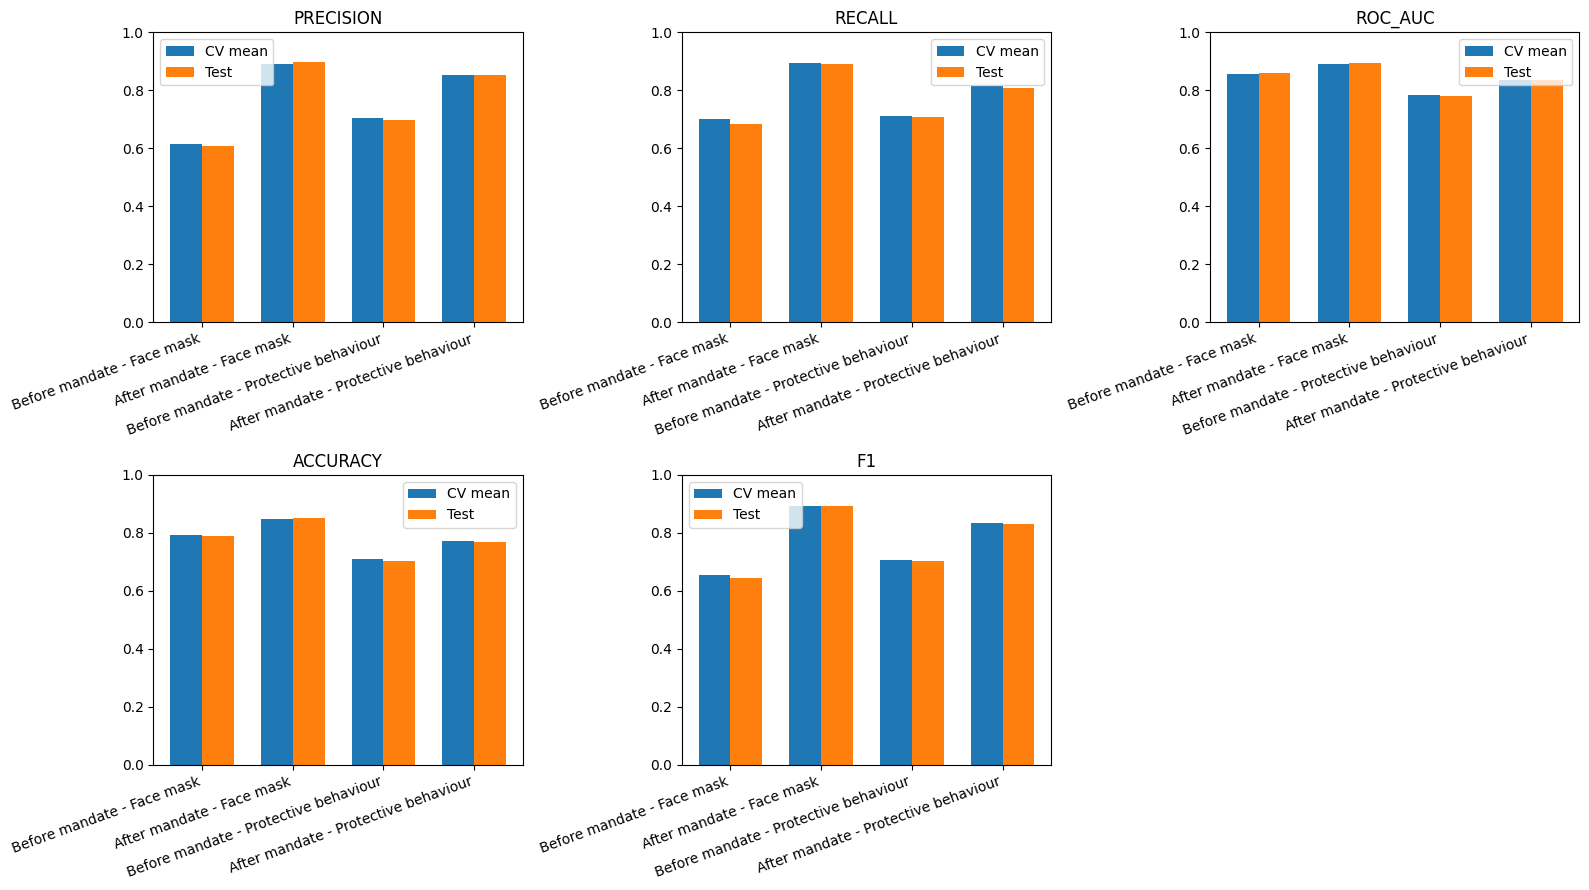

In [10]:
# Compare cross-validation and test performance for each evaluation metric.
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()


for i, metric in enumerate(METRICS):
    ax = axes[i]
    cv_vals = cv_summary_df.set_index("task").loc[list(TASKS.keys()), metric]
    test_vals = test_summary_df.set_index("task").loc[list(TASKS.keys()), metric]
    x = np.arange(len(TASKS))
    width = 0.35

    ax.bar(x - width / 2, cv_vals.values, width=width, label="CV mean")
    ax.bar(x + width / 2, test_vals.values, width=width, label="Test")
    ax.set_xticks(x)
    ax.set_xticklabels(list(TASKS.values()), rotation=20, ha="right")
    ax.set_ylim(0, 1)
    ax.set_title(metric.upper())
    ax.legend()


axes[-1].axis("off")
plt.tight_layout()
plt.show()


### 4.6 ROC curve


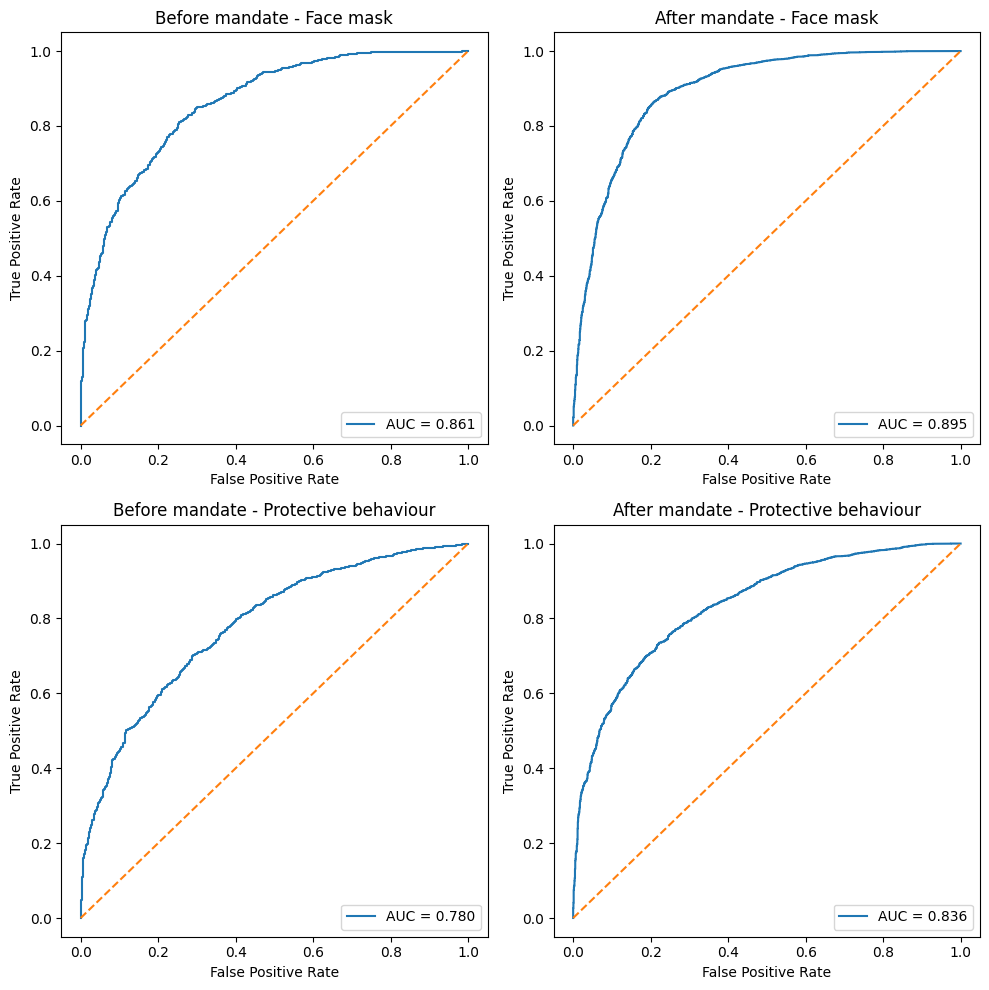

In [11]:
# Plot ROC curves for the four tasks using test-set predicted probabilities.
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()


for ax, task in zip(axes, TASKS.keys()):
    y_test = results[task]["y_test"]
    y_prob = results[task]["y_test_prob"]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    ax.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_title(TASKS[task])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right")


plt.tight_layout()
plt.show()


### 4.7 Confusion matrix heatmap


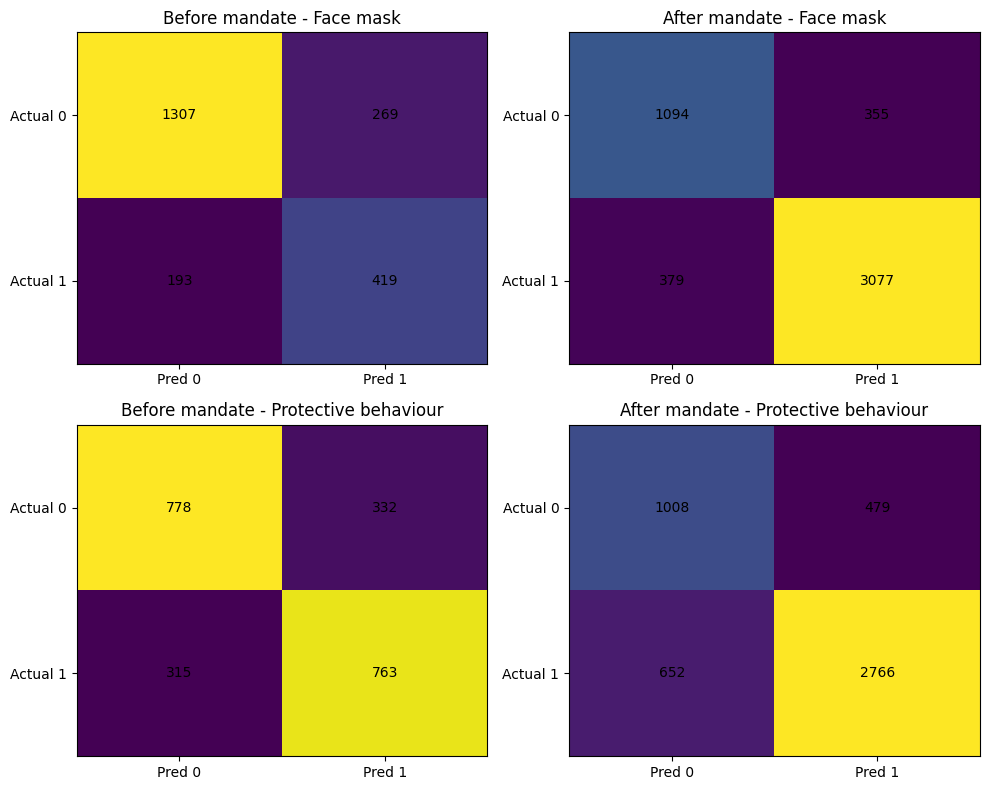

In [12]:
# Plot confusion matrices to show the number of correct and incorrect predictions.
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()


for ax, task in zip(axes, TASKS.keys()):
    cm = results[task]["cm"]

    ax.imshow(cm, aspect="auto")
    ax.set_title(TASKS[task])
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred 0", "Pred 1"])
    ax.set_yticklabels(["Actual 0", "Actual 1"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm[i, j]}", ha="center", va="center")


# Visualization
plt.tight_layout()
plt.show()


### 4.8 Top feature importance


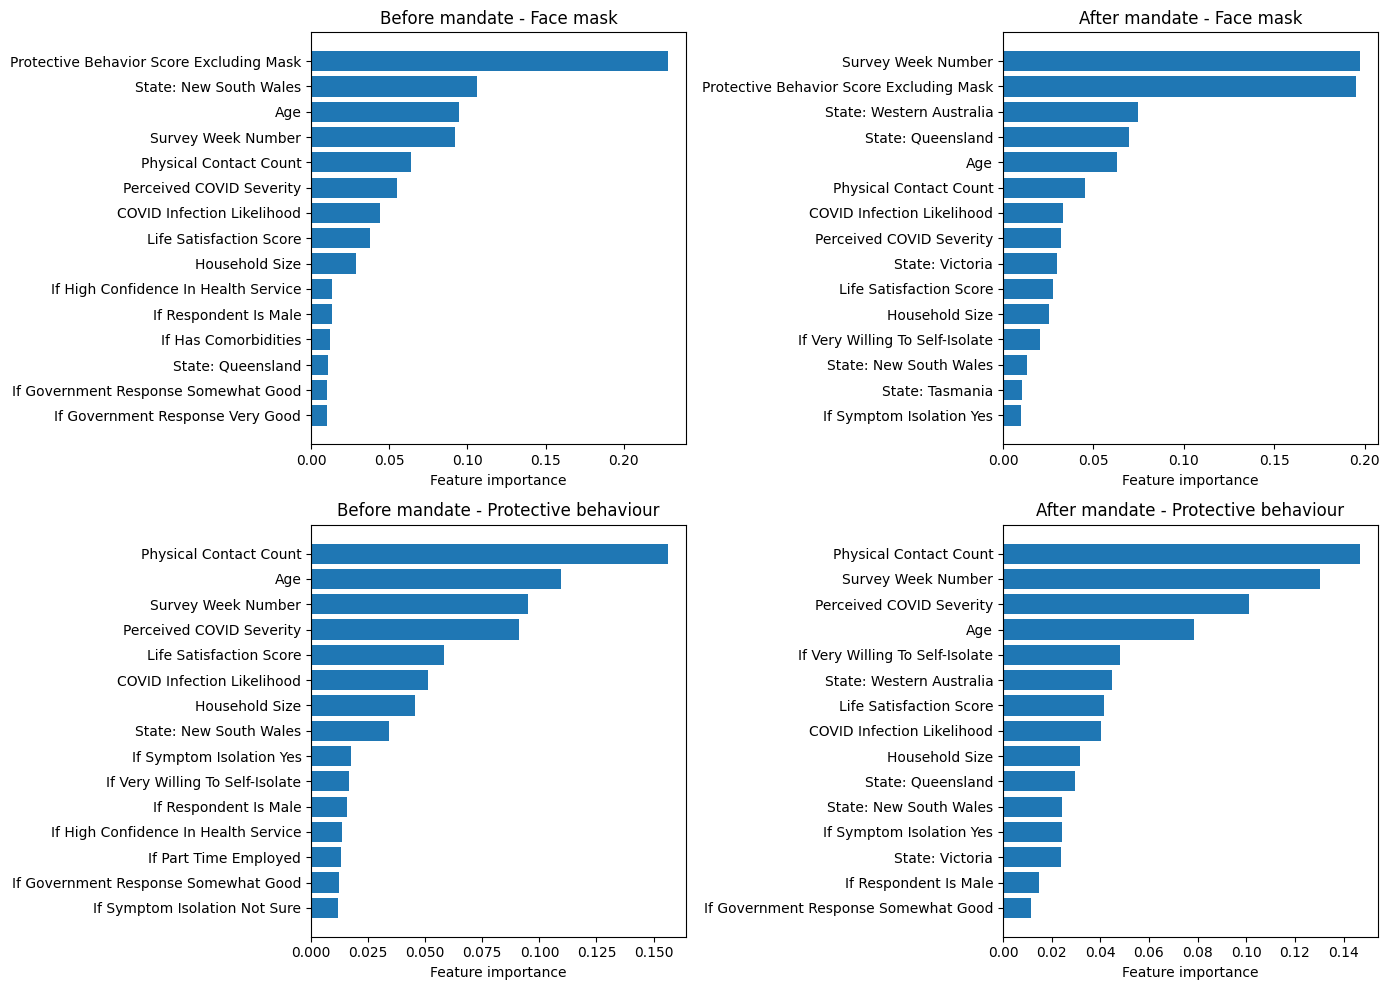

In [16]:
# Plot the top feature importances from the fitted Random Forest models.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()


for ax, task in zip(axes, TASKS.keys()):
    importance_df = results[task]["importance_df"]
    top_df = importance_df.head(TOP_N_FEATURES).sort_values("importance", ascending=True)

    ax.barh(top_df["feature"], top_df["importance"])
    ax.set_title(TASKS[task])
    ax.set_xlabel("Feature importance")


# Visualization
plt.tight_layout()
plt.show()


### 4.9 All Model Indicators


In [15]:
# Combine the main CV and test indicators into one summary table.
metric_order = ["roc_auc", "f1", "accuracy", "precision", "recall"]
metric_names = {"roc_auc": "AUC", "f1": "F1", "accuracy": "Accuracy", "precision": "Precision", "recall": "Recall"}

task_order = list(TASKS.keys())

cv_tbl = (cv_summary_df.set_index("task").loc[task_order, ["label"] + metric_order].copy())
test_tbl = (test_summary_df.set_index("task").loc[task_order, metric_order].copy())


summary_table = pd.DataFrame({"Task": cv_tbl["label"].values})


for metric in metric_order:
    summary_table[f"CV {metric_names[metric]}"] = cv_tbl[metric].round(3).values
    summary_table[f"Test {metric_names[metric]}"] = test_tbl[metric].round(3).values


# Visualization
display(summary_table)

,Task,CV AUC,Test AUC,CV F1,Test F1,CV Accuracy,Test Accuracy,CV Precision,Test Precision,CV Recall,Test Recall
0,Before mandate - Face mask,0.857,0.861,0.655,0.645,0.794,0.789,0.616,0.609,0.701,0.685
1,After mandate - Face mask,0.890,0.895,0.892,0.893,0.847,0.850,0.890,0.897,0.893,0.890
2,Before mandate - Protective behaviour,0.785,0.780,0.707,0.702,0.710,0.704,0.704,0.697,0.711,0.708
3,After mandate - Protective behaviour,0.835,0.836,0.833,0.830,0.773,0.769,0.854,0.852,0.814,0.809
